In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [2]:
from Energy_NN_architectures import *

K_init = jnp.array([2.0, 0.001, 0.02])

train_data = "../data/output_old.npz"
valid_data = "../data/output_valid.npz"

train_file = "training_data.npz"
valid_file = "validation_data.npz"
# convert to direct-BC format
convert_linear_bc_to_direct_bc(train_data, train_file, lambdas=None)
convert_linear_bc_to_direct_bc(valid_data, valid_file, lambdas=None)


Saved converted direct-BC dataset to: training_data.npz
qs.shape      = (1, 11, 11)
xb.shape      = (1, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)
Saved converted direct-BC dataset to: validation_data.npz
qs.shape      = (1, 11, 11)
xb.shape      = (1, 11, 8)
idx_b.shape   = (8,)
lambdas.shape = (11,)


In [3]:

final_model, train_history, valid_history = train_model(CholeskyPlusEnergyNN, key=jax.random.PRNGKey(42), train_file=train_file, valid_file=valid_file, n_epochs=500, lr=1e-2, init_K=K_init )

Epoch 000 | Train: 1.800e-04 | Valid: 2.062e-04
Epoch 010 | Train: 8.910e-06 | Valid: 2.970e-05
Epoch 020 | Train: 1.242e-05 | Valid: 3.835e-05
Epoch 030 | Train: 9.937e-06 | Valid: 3.383e-05
Epoch 040 | Train: 5.547e-06 | Valid: 2.901e-05
Epoch 050 | Train: 6.105e-06 | Valid: 2.960e-05
Epoch 060 | Train: 5.396e-06 | Valid: 2.992e-05
Epoch 070 | Train: 5.354e-06 | Valid: 3.096e-05
Epoch 080 | Train: 5.173e-06 | Valid: 3.128e-05
Epoch 090 | Train: 5.065e-06 | Valid: 3.185e-05
Epoch 100 | Train: 4.936e-06 | Valid: 3.286e-05
Epoch 110 | Train: 4.814e-06 | Valid: 3.390e-05
Epoch 120 | Train: 4.686e-06 | Valid: 3.485e-05
Epoch 130 | Train: 4.557e-06 | Valid: 3.600e-05
Epoch 140 | Train: 4.426e-06 | Valid: 3.731e-05
Epoch 150 | Train: 4.293e-06 | Valid: 3.866e-05
Epoch 160 | Train: 4.159e-06 | Valid: 4.012e-05
Epoch 170 | Train: 4.024e-06 | Valid: 4.172e-05
Epoch 180 | Train: 3.889e-06 | Valid: 4.341e-05
Epoch 190 | Train: 3.754e-06 | Valid: 4.521e-05
Epoch 200 | Train: 3.620e-06 | Valid: 4.

500


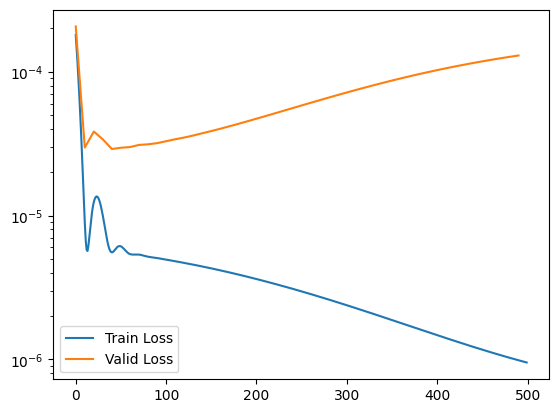

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()